# Notebook 8 — Correlation Analysis: Hospitalisation vs. Resource Consumption

## Purpose

This notebook investigates the statistical association between hospitalisation outcome and the resource consumption variables used in clustering, as a pre-clustering validation step. The goal is to confirm that the chosen features carry discriminant signal before engaging the full HDBSCAN pipeline.

---

## Pipeline Overview

### 1. Frequency audit of clustering variables
All binary variables from Scenario 2 (imaging modalities, biology flags, EKG, disposition) are screened for prevalence. Variables falling below 5% or above 95% are flagged as too sparse or quasi-constant, ensuring they do not distort the distance matrix.

### 2. Point-biserial correlations — resource consumption vs. hospitalisation
For each continuous or binary resource consumption variable in Scenario 2, a point-biserial correlation coefficient is computed against the binary `hospitalization` target. Results are sorted by absolute correlation strength and flagged for significance (p < 0.05).

### 3. Broader association analysis — triage and admission variables vs. hospitalisation
A second analysis covers all admission-level and triage variables:
- **Binary `is_*_measured` flags** → point-biserial r (measurement presence vs. hospitalisation)
- **Categorical `*_status` fields** (vital sign severity levels) → Cramér's V
- **Continuous variables** (age, triage score, triage duration) → point-biserial r
- **Nominal variables** (age group, sex, transport mode, chief complaint) → Cramér's V

### 4. Summary visualisation
A unified horizontal bar chart plots association strength (|r_pb| or Cramér's V) for all tested variables, colour-coded by statistical significance. The plot is exported as `correlation_vs_hospitalization.png`.

In [1]:
# ==============================================================================
# CLUSTERING PIPELINE — SPLIT DATASET — HDBSCAN
# pour 30000 patients → GPU ok
# pour 120000 patients → basculer sur CPU (voir compute_distance_matrix commenté)
# ==============================================================================


# ==============================================================================
# 0. CONFIGURATION
# ==============================================================================

# ── Paths ──────────────────────────────────────────────────────────────────────
CSV_PATH   = "Datasets/df_final_binaire_imputed.csv"
OUTPUT_DIR = "Results/correlation"


# ── GPU ────────────────────────────────────────────────────────────────────────
GPU_DEVICE_ID = 1



# ==============================================================================
# 1. IMPORTS
# ==============================================================================

import os
import logging
import time

import gower
import hdbscan
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import torch
import umap
import umap.umap_ as umap_reduce
from scipy.stats import pointbiserialr

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.manifold import TSNE
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

log = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── GPU setup ──────────────────────────────────────────────────────────────────
torch.cuda.set_device(GPU_DEVICE_ID)
torch.cuda.set_per_process_memory_fraction(0.5, device=GPU_DEVICE_ID)
print(f"GPU : {torch.cuda.get_device_name(GPU_DEVICE_ID)}")
print(f"Mémoire disponible : {torch.cuda.get_device_properties(GPU_DEVICE_ID).total_memory / 1e9:.0f} GB")


# ==============================================================================
# 2. COLUMN DEFINITIONS
# ==============================================================================

IMAGING_COLS_BOOL = {
    "has_ultrasound", "has_ct_scan", "has_xray",
    "has_mri",
    #"has_radio_interventional", "has_nuclear_medicine",
}


BIO_EXAMS = {
    "has_blood_test", "has_culture",
    "has_lumbar_puncture", "has_blood_gas",
}

PROCEDURE_COLS   = {"had_ekg"}
DISPOSITION_COLS = {
    "hospitalization", "observation_unit",
    #"inter_facility_transfer",
}

COLS_QUANTI = ["imaging_exam_count", "bio_exam_count"]

COLS_BINARY    = list(IMAGING_COLS_BOOL | BIO_EXAMS | PROCEDURE_COLS | DISPOSITION_COLS)


SCENARIOS = {
    "scenario_2": list(
        IMAGING_COLS_BOOL | BIO_EXAMS | PROCEDURE_COLS | DISPOSITION_COLS
    ) + COLS_QUANTI
}




# ==============================================================================
# 3. CORRELATION ANALYSIS BETWEEN HOSPITALIZATION AND CONSO VARIABLES
# ==============================================================================
# ==============================================================================
df = pd.read_csv(CSV_PATH, low_memory=False)


binary_vars_s2 = SCENARIOS["scenario_2"]  # toutes les variables, hospitalization incluse

freq_df = pd.DataFrame({
    "variable": binary_vars_s2,
    "freq_1_pct": [round(df[v].mean() * 100, 1) for v in binary_vars_s2],
    "n_1":        [int(df[v].sum())              for v in binary_vars_s2],
    "n_total":    [int(df[v].notna().sum())       for v in binary_vars_s2],
}).sort_values("freq_1_pct")

freq_df["statut"] = freq_df["freq_1_pct"].apply(
    lambda x: "trop sparse"    if x < 5
    else      "quasi-constant" if x > 95
    else      "limite"         if x < 10 or x > 90
    else      "ok"
)

print(freq_df.to_string(index=False))




# ==============================================================================
# 4. CORRELATION ANALYSIS BETWEEN HOSPITALIZATION AND CONSO VARIABLES



# Ta variable cible
target = "hospitalization"

# Les variables à tester (scenario_2 sans la cible elle-même)
vars_to_test = [col for col in SCENARIOS["scenario_2"] if col != target]

# Calcul des corrélations
results = []
for col in vars_to_test:
    corr, pvalue = pointbiserialr(df[col], df[target])
    results.append({
        "variable": col,
        "correlation": round(corr, 3),
        "pvalue": round(pvalue, 4),
        "significatif": "✓" if pvalue < 0.05 else "✗"
    })

# Mise en forme et tri par corrélation absolue
results_df = pd.DataFrame(results)
results_df = results_df.reindex(
    results_df["correlation"].abs().sort_values(ascending=False).index
)

print(results_df.to_string(index=False))

GPU : NVIDIA A100-SXM4-80GB
Mémoire disponible : 85 GB
           variable  freq_1_pct   n_1  n_total      statut
has_lumbar_puncture         0.8   470    56784 trop sparse
     has_ultrasound         1.6   913    56784 trop sparse
      has_blood_gas         7.8  4448    56784      limite
            has_mri         9.6  5444    56784      limite
        has_culture        14.5  8214    56784          ok
   observation_unit        19.6 11102    56784          ok
           has_xray        23.0 13048    56784          ok
        has_ct_scan        25.1 14253    56784          ok
            had_ekg        28.0 15924    56784          ok
    hospitalization        54.3 30837    56784          ok
     has_blood_test        58.5 33230    56784          ok
 imaging_exam_count        60.9 34578    56784          ok
     bio_exam_count        81.6 46362    56784          ok
           variable  correlation  pvalue significatif
     has_blood_test        0.666  0.0000            ✓
     bio_ex

▶ Binary vars (is_* measured)  →  Point-Biserial r
                          variable   r_pb  p_value significant
                    is_o2_measured 0.4551      0.0           ✓
                  is_pain_measured 0.4378      0.0           ✓
                   is_sat_measured 0.4141      0.0           ✓
                    is_bp_measured 0.4139      0.0           ✓
                  is_temp_measured 0.4057      0.0           ✓
                   is_gcs_measured 0.3961      0.0           ✓
is_cap_blood_sugar_mmol_L_measured 0.3643      0.0           ✓
                    is_rr_measured 0.3341      0.0           ✓
  is_urine_dipstick_clean_measured 0.1361      0.0           ✓
               is_hemocue_measured 0.0782      0.0           ✓
          is_breathalyzer_measured 0.0306      0.0           ✓

▶ Status vars (*_status)  →  Cramér's V
                   variable  cramers_v  p_value significant
                pain_status     0.4682      0.0           ✓
             o2_flow_status     

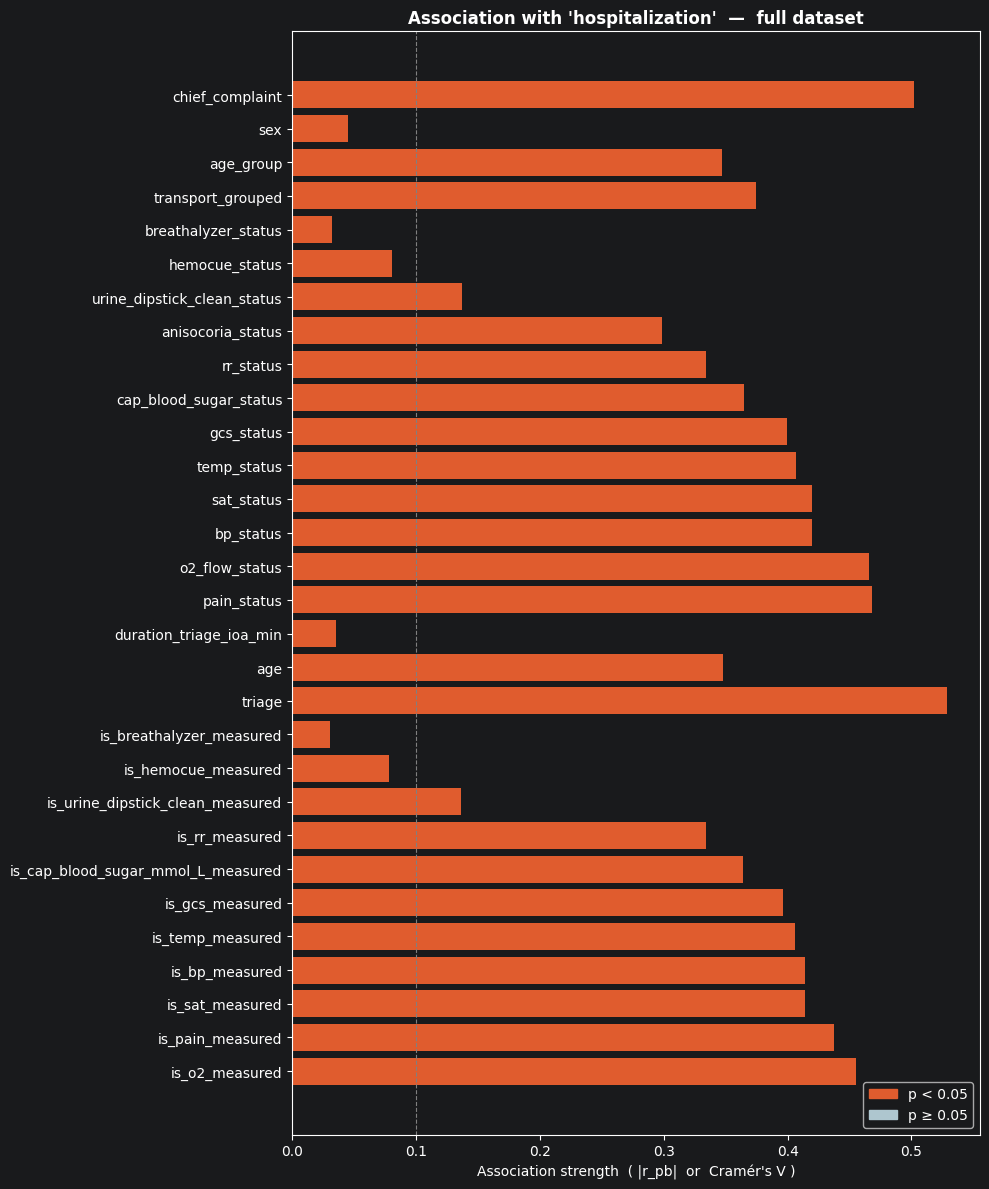

In [2]:
# ==============================================================================
# 5. CORRELATION ANALYSIS BETWEEN HOSPITALIZATION AND TRIAGE SOCIO DEMO VARIABLES
# ==============================================================================






import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

MEASURED_STATUS_PAIRS = {
    "is_bp_measured":                     "bp_status",
    "is_ht_measured":                     "ht_status",
    "is_temp_measured":                   "temp_status",
    "is_sat_measured":                    "sat_status",
    "is_rr_measured":                     "rr_status",
    "is_o2_measured":                     "o2_flow_status",
    "is_gcs_measured":                    "gcs_status",
    "is_cap_blood_sugar_mmol_L_measured": "cap_blood_sugar_status",
    "is_pupil_right_measured":            "anisocoria_status",
    "is_urine_dipstick_clean_measured":   "urine_dipstick_clean_status",
    "is_pain_measured":                   "pain_status",
    "is_breathalyzer_measured":           "breathalyzer_status",
    "is_hemocue_measured":                "hemocue_status",
}

ADMISSION_QUANTI = ["age", "duration_triage_ioa_min", "triage"]
ADMISSION_CATEG  = ["age_group", "sex", "transport_grouped"]
CHIEF_COMPLAINT_COL = "chief_complaint"
TOP_N_COMPLAINTS    = 10

TARGET = "hospitalization"

# ── 1. Séparer les types de variables ────────────────────────────────────────
binary_vars  = list(MEASURED_STATUS_PAIRS.keys())          # is_* → binaires 0/1
status_vars  = list(MEASURED_STATUS_PAIRS.values())        # *_status → catégorielles
quanti_vars  = ADMISSION_QUANTI                            # numériques continues
categ_vars   = ADMISSION_CATEG                             # catégorielles nominales


# ── 2. Corrélation Point-Bisérial (binaire / quanti vs target binaire) ───────
def pointbiserial_table(df, vars_, target=TARGET):
    rows = []
    for v in vars_:
        if v not in df.columns:
            continue
        col = df[v].dropna()
        tgt = df.loc[col.index, target]
        r, p = stats.pointbiserialr(col, tgt)
        rows.append({"variable": v, "r_pb": round(r, 4), "p_value": round(p, 6),
                     "significant": "✓" if p < 0.05 else "✗"})
    return pd.DataFrame(rows).sort_values("r_pb", key=abs, ascending=False)


# ── 3. Cramér's V (catégorielle vs target binaire) ───────────────────────────
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

def cramersv_table(df, vars_, target=TARGET):
    rows = []
    for v in vars_:
        if v not in df.columns:
            continue
        mask = df[v].notna() & df[target].notna()
        v_cv = cramers_v(df.loc[mask, v].astype(str), df.loc[mask, target])
        ct   = pd.crosstab(df.loc[mask, v], df.loc[mask, target])
        chi2, p, _, _ = stats.chi2_contingency(ct, correction=False)
        rows.append({"variable": v, "cramers_v": round(v_cv, 4), "p_value": round(p, 6),
                     "significant": "✓" if p < 0.05 else "✗"})
    return pd.DataFrame(rows).sort_values("cramers_v", ascending=False)


# ── 4. Top-N chief complaints ─────────────────────────────────────────────────
def top_complaints_table(df, col=CHIEF_COMPLAINT_COL, n=TOP_N_COMPLAINTS, target=TARGET):
    top = df[col].value_counts().head(n).index
    mask = df[col].isin(top)
    return cramersv_table(df[mask].assign(**{col: df.loc[mask, col]}), [col], target)


# ── 5. Run all ────────────────────────────────────────────────────────────────
print("=" * 60)
print("▶ Binary vars (is_* measured)  →  Point-Biserial r")
print("=" * 60)
pb_binary = pointbiserial_table(df, binary_vars)
print(pb_binary.to_string(index=False))

print("\n" + "=" * 60)
print("▶ Status vars (*_status)  →  Cramér's V")
print("=" * 60)
cv_status = cramersv_table(df, status_vars)
print(cv_status.to_string(index=False))

print("\n" + "=" * 60)
print("▶ Quantitative vars  →  Point-Biserial r")
print("=" * 60)
pb_quanti = pointbiserial_table(df, quanti_vars)
print(pb_quanti.to_string(index=False))

print("\n" + "=" * 60)
print("▶ Categorical admission vars  →  Cramér's V")
print("=" * 60)
cv_categ = cramersv_table(df, categ_vars)
print(cv_categ.to_string(index=False))

print("\n" + "=" * 60)
print(f"▶ Chief complaint (top {TOP_N_COMPLAINTS})  →  Cramér's V")
print("=" * 60)
cv_cc = cramersv_table(df, [CHIEF_COMPLAINT_COL])
print(cv_cc.to_string(index=False))


# ── 6. Summary plot ───────────────────────────────────────────────────────────
def build_summary(pb_df, cv_df, metric_col):
    """Merge point-biserial and cramér results into one plottable df."""
    pb = pb_df.rename(columns={"r_pb": "strength"}).assign(metric="|r_pb|")
    pb["strength"] = pb["strength"].abs()
    cv = cv_df.rename(columns={metric_col: "strength"}).assign(metric="Cramér V")
    return pd.concat([pb[["variable","strength","metric","significant"]],
                      cv[["variable","strength","metric","significant"]]], ignore_index=True)

summary = build_summary(
    pd.concat([pb_binary, pb_quanti]),
    pd.concat([cv_status, cv_categ, cv_cc]),
    "cramers_v"
)

fig, ax = plt.subplots(figsize=(10, max(5, len(summary) * 0.4)))
colors = summary["significant"].map({"✓": "#e05c2e", "✗": "#aec6cf"})
bars = ax.barh(summary["variable"], summary["strength"], color=colors)
ax.axvline(0.1, color="gray", linestyle="--", linewidth=0.8, label="weak threshold (0.1)")
ax.set_xlabel("Association strength  ( |r_pb|  or  Cramér's V )")
ax.set_title(f"Association with '{TARGET}'  —  full dataset", fontweight="bold")
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#e05c2e", label="p < 0.05"),
    plt.Rectangle((0,0),1,1, color="#aec6cf", label="p ≥ 0.05"),
], loc="lower right")
plt.tight_layout()
plt.savefig("correlation_vs_hospitalization.png", dpi=150)
plt.show()